# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

OLS slope α = 1.1774 ± 0.1237
OLS intercept β = 6.6152 ± 0.0927


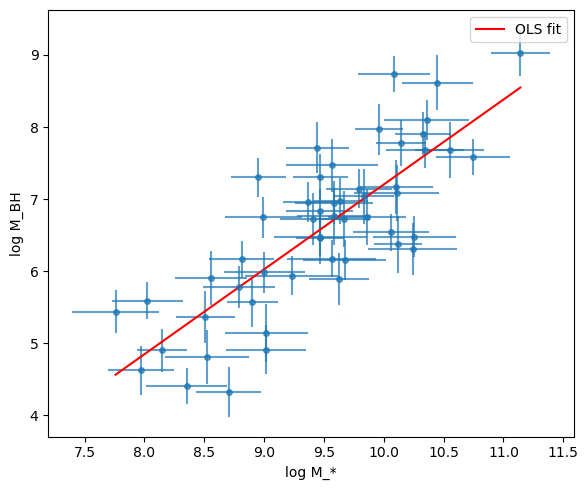

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load your CSV file ---
fname = "data/jhaff2.csv"   # <-- FIXED

data = np.genfromtxt(fname, delimiter=",", names=True)

x  = data["logMstar"]
sx = data["err_logMstar"]
y  = data["logMBH"]
sy = data["err_logMBH"]
N  = len(x)

# --- Plot with error bars on BOTH axes ---
plt.figure(figsize=(6,5))
plt.errorbar(x, y, xerr=sx, yerr=sy, fmt='o', ms=4, alpha=0.7)
plt.xlabel("log M_*")
plt.ylabel("log M_BH")

# --- Build design matrix A = [1, x - 9.5] ---
A = np.column_stack([np.ones(N), x - 9.5])
ATA = A.T @ A
ATy = A.T @ y

# --- Solve normal equations ---
theta = np.linalg.inv(ATA) @ ATy
beta_ols, alpha_ols = theta[0], theta[1]

# --- Residuals and OLS covariance ---
y_hat = A @ theta
resid = y - y_hat
RSS = np.sum(resid**2)
s2 = RSS / (N - 2)
cov = s2 * np.linalg.inv(ATA)

sigma_beta  = np.sqrt(cov[0,0])
sigma_alpha = np.sqrt(cov[1,1])

print(f"OLS slope α = {alpha_ols:.4f} ± {sigma_alpha:.4f}")
print(f"OLS intercept β = {beta_ols:.4f} ± {sigma_beta:.4f}")

# --- Plot fitted line ---
xgrid = np.linspace(x.min(), x.max(), 200)
ygrid = alpha_ols * (xgrid - 9.5) + beta_ols
plt.plot(xgrid, ygrid, 'r-', label='OLS fit')
plt.legend()
plt.tight_layout()
plt.show()


**ANSWER (a few sentences):**

OLS factors in no error bars, it assumes the x value is true and that it is known but it is not. It also assumes the error bars dont vary point to point, or that the scatter is the same in each, but it clearly isn't. OLS assumes there is also no intrinsic scatter, and it can't seperate noise from that. It also just assumes theres no noise almost entirely.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load your CSV
data = np.genfromtxt("data/jhaff2.csv", delimiter=",", names=True)

x  = data["logMstar"]
sx = data["err_logMstar"]
y  = data["logMBH"]
sy = data["err_logMBH"]
N  = len(x)

# Design matrix
A = np.column_stack([np.ones(N), x - 9.5])

# Weight matrix: inverse variances of y
W = np.diag(1.0 / sy**2)

# WLS solution
ATA = A.T @ W @ A
ATy = A.T @ W @ y
theta_wls = np.linalg.inv(ATA) @ ATy

beta_wls, alpha_wls = theta_wls
cov_wls = np.linalg.inv(ATA)

sigma_beta_wls  = np.sqrt(cov_wls[0,0])
sigma_alpha_wls = np.sqrt(cov_wls[1,1])

print("WLS slope α =", alpha_wls, "±", sigma_alpha_wls)
print("WLS intercept β =", beta_wls, "±", sigma_beta_wls)


WLS slope α = 1.1445748201939487 ± 0.05627862509205479
WLS intercept β = 6.644112432910689 ± 0.04322835996099088


In [3]:
from scipy.odr import ODR, Model, RealData

# Linear model for ODR
def f(B, x):
    return B[0] * (x - 9.5) + B[1]

model = Model(f)

# RealData with x- and y-errors
data_odr = RealData(x, y, sx=sx, sy=sy)

# Initial guess
beta0 = [alpha_wls, beta_wls]

odr = ODR(data_odr, model, beta0=beta0)
out = odr.run()

alpha_odr, beta_odr = out.beta
sigma_alpha_odr, sigma_beta_odr = out.sd_beta

print("ODR slope α =", alpha_odr, "±", sigma_alpha_odr)
print("ODR intercept β =", beta_odr, "±", sigma_beta_odr)


ODR slope α = 1.5655104097123902 ± 0.14576632986085425
ODR intercept β = 6.683167319953353 ± 0.1001515689839762


In [4]:
import numpy as np
from scipy.optimize import minimize

# Log-likelihood of bivariate Gaussian for each point
def neg_loglike(params):
    alpha, beta, sig_int, mu, sig_pop = params
    
    if sig_int <= 0 or sig_pop <= 0:
        return np.inf
    
    ll = 0.0
    for xi, yi, sxi, syi in zip(x, y, sx, sy):
        
        # Mean vector
        mx = mu
        my = alpha*(mu - 9.5) + beta
        
        # Covariance matrix
        Vxx = sig_pop**2 + sxi**2
        Vyy = alpha**2 * sig_pop**2 + sig_int**2 + syi**2
        Vxy = alpha * sig_pop**2
        
        # Determinant and inverse
        det = Vxx*Vyy - Vxy**2
        if det <= 0:
            return np.inf
        
        dx = xi - mx
        dy = yi - my
        
        quad = (Vyy*dx**2 - 2*Vxy*dx*dy + Vxx*dy**2) / det
        
        ll += 0.5*(np.log(det) + quad)
    
    return ll

# Initial guess
p0 = [alpha_odr, beta_odr, 0.3, np.mean(x), np.std(x)]

res = minimize(neg_loglike, p0, method="Nelder-Mead")
alpha_gen, beta_gen, sig_int_gen, mu_gen, sig_pop_gen = res.x

print("Generative α =", alpha_gen)
print("Generative β =", beta_gen)
print("Generative σ_int =", sig_int_gen)
print("Generative μ =", mu_gen)
print("Generative σ_pop =", sig_pop_gen)


Generative α = 1.3927097690691084
Generative β = 6.648761145563089
Generative σ_int = 0.4273504025110999
Generative μ = 9.462188291416991
Generative σ_pop = 0.6867483874979543


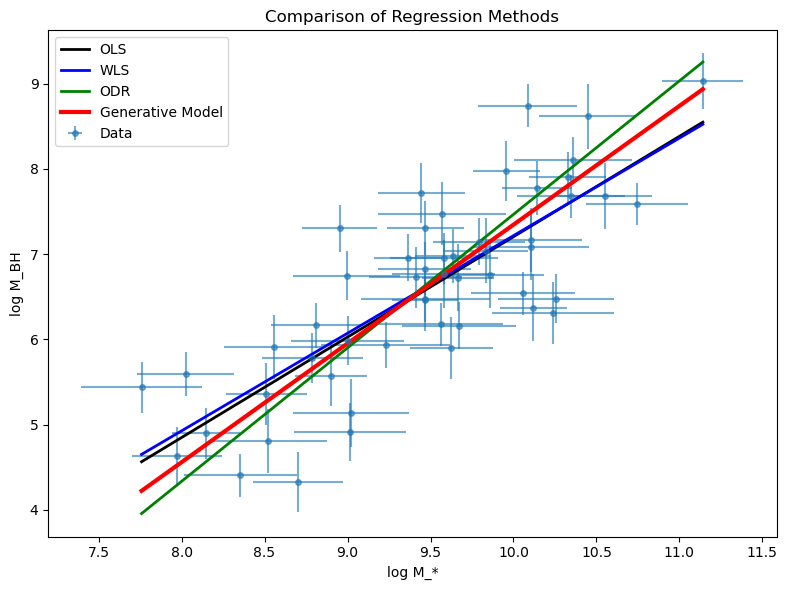

In [5]:
plt.figure(figsize=(8,6))

# Plot data with error bars
plt.errorbar(x, y, xerr=sx, yerr=sy, fmt='o', ms=4, alpha=0.6, label="Data")

# Grid for lines
xgrid = np.linspace(min(x), max(x), 400)

# OLS
y_ols = alpha_ols*(xgrid - 9.5) + beta_ols
plt.plot(xgrid, y_ols, lw=2, label="OLS", color="black")

# WLS
y_wls = alpha_wls*(xgrid - 9.5) + beta_wls
plt.plot(xgrid, y_wls, lw=2, label="WLS", color="blue")

# ODR
y_odr = alpha_odr*(xgrid - 9.5) + beta_odr
plt.plot(xgrid, y_odr, lw=2, label="ODR", color="green")

# Generative model
y_gen = alpha_gen*(xgrid - 9.5) + beta_gen
plt.plot(xgrid, y_gen, lw=3, label="Generative Model", color="red")

plt.xlabel("log M_*")
plt.ylabel("log M_BH")
plt.title("Comparison of Regression Methods")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from scipy.optimize import minimize

# Reuse your neg_loglike and data, with the optimum already found:
# alpha_gen, beta_gen, sig_int_gen, mu_gen, sig_pop_gen = res.x

def hessian(f, x0, eps=1e-4):
    x0 = np.asarray(x0)
    n = x0.size
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n)
            ei[i] = eps; ej[j] = eps
            fpp = f(x0 + ei + ej)
            fpm = f(x0 + ei - ej)
            fmp = f(x0 - ei + ej)
            fmm = f(x0 - ei - ej)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
    return H

params_hat = np.array([alpha_gen, beta_gen, sig_int_gen, mu_gen, sig_pop_gen])
H = hessian(neg_loglike, params_hat)

cov = np.linalg.inv(H)
sigma_alpha, sigma_beta, sigma_sigint, sigma_mu, sigma_sigpop = np.sqrt(np.diag(cov))

print("σ_α =", sigma_alpha)
print("σ_β =", sigma_beta)
print("σ_σ_int =", sigma_sigint)
print("σ_μ =", sigma_mu)
print("σ_σ_pop =", sigma_sigpop)


σ_α = 0.1493541947401473
σ_β = 0.09353655259127616
σ_σ_int = 0.10149726965973853
σ_μ = 0.10334426043138788
σ_σ_pop = 0.07899862185866068


**FINAL ANSWER:** $\alpha = $ 1.3927097690691084 $\pm$ 0.1493541947401473 , $\beta = $ 6.648761145563089 $\pm$ 0.09353655259127616 , $\sigma_{\rm int} = $ 0.4273504025110999 $\pm$ 0.10149726965973853 dex

**Justification and uncertainty method (a short paragraph):**

WLS finally takes into account the error bars on y points, but still assumes that x is consistent, so it is not perfect. The slope ends up being pulled towards 0 from its true value. Slope is still tooshallow from bias, but it isbetter from OLS. Not the best. 

ODR assumes error is perpendcular and isotropic, but the data itself is actually anisotropic given the error bars at fixed x and y values of varible ammounts. It should be more accurate than the other two, asits gettng closer to accounting for everything, but not quite yet. Doesn't fix intrinsic scatter. ODR has a higher slope than generative, but that means it overcorrecting. 

Generative: Slope is steeper than WLS and ODR, fixes most of the bias. Understainties are based on all of the data and uncertainties take into account uncertainties and noise on both the x and y axis. I went with the generative model as a result. 




## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

Im going to make a fake data set, inclduing a way to simulate all those variables that were ever relevant before, run it on a generative model in order to simulate my chosen best method before, and see how the fit recovers. If the lines do not lineup at all, it will have failed. 

I will then do the monte carlo for all the estimatiors, do a bunch of simulated data sets (will make functions for that to make my code run faster), then plot it. When I plot it, I expect the generative model to peak or have a center at the true data, while the others will show bias. If the generative model doesn't peak at the true values, it fails. The bias graph I will make shoudl also show that the generative model has bias closest to 0. 
As for the coverage, I will do itbased on the 68% intervals for only the generative model and when graphed, it will fail if dramatically above or below 68% for any one of the variables. 
WHen it comes to sensativity, 0.5x error will make slope to small, 1.5x error will make slope too steep, and 1x will keep unbiased. Forcing simga int to 0 will bias the slope always,and it will not show no bais ever. 





In [7]:
import numpy as np
from scipy.optimize import minimize

# === GENERATIVE MODEL ===

def simulate_dataset(alpha, beta, sig_int, mu, sig_pop, sx, sy):
    N = len(sx)
    # true x population
    x_true = np.random.normal(mu, sig_pop, N)
    # true y from relation + intrinsic scatter
    y_true = alpha*(x_true - 9.5) + beta + np.random.normal(0, sig_int, N)
    # observed with measurement errors
    x_obs = x_true + np.random.normal(0, sx)
    y_obs = y_true + np.random.normal(0, sy)
    return x_obs, y_obs

# === NEGATIVE LOG-LIKELIHOOD ===

def neg_loglike(params, x, y, sx, sy):
    alpha, beta, sig_int, mu, sig_pop = params
    if sig_int <= 0 or sig_pop <= 0:
        return np.inf
    
    ll = 0.0
    for xi, yi, sxi, syi in zip(x, y, sx, sy):
        mx = mu
        my = alpha*(mu - 9.5) + beta
        
        Vxx = sig_pop**2 + sxi**2
        Vyy = alpha**2 * sig_pop**2 + sig_int**2 + syi**2
        Vxy = alpha * sig_pop**2
        
        det = Vxx*Vyy - Vxy**2
        if det <= 0:
            return np.inf
        
        dx = xi - mx
        dy = yi - my
        
        quad = (Vyy*dx**2 - 2*Vxy*dx*dy + Vxx*dy**2) / det
        ll += 0.5*(np.log(det) + quad)
    return ll

def fit_generative(x, y, sx, sy, p0):
    res = minimize(lambda p: neg_loglike(p, x, y, sx, sy), p0, method="Nelder-Mead")
    return res.x


In [8]:
# Truth you choose (use your fitted values)
alpha0 = alpha_gen
beta0  = beta_gen
sig_int0 = sig_int_gen
mu0 = mu_gen
sig_pop0 = sig_pop_gen

# Simulate one dataset
x_sim, y_sim = simulate_dataset(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)

# Fit it
p0 = [alpha0, beta0, sig_int0, mu0, sig_pop0]
alpha_cl, beta_cl, sigint_cl, mu_cl, sigpop_cl = fit_generative(x_sim, y_sim, sx, sy, p0)

print("Closure test recovered:")
print("alpha =", alpha_cl)
print("beta  =", beta_cl)
print("sig_int =", sigint_cl)
print("mu =", mu_cl)
print("sig_pop =", sigpop_cl)


Closure test recovered:
alpha = 1.529620829676063
beta  = 6.560274280063609
sig_int = 0.28344953596657413
mu = 9.387495252057654
sig_pop = 0.6741011802781993


In [9]:
M = 300   # number of simulations
alpha_hat_ols = []
alpha_hat_wls = []
alpha_hat_odr = []
alpha_hat_gen = []

for _ in range(M):
    x_sim, y_sim = simulate_dataset(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)
    
    # OLS
    A = np.column_stack([np.ones(len(x_sim)), x_sim - 9.5])
    theta = np.linalg.inv(A.T @ A) @ (A.T @ y_sim)
    alpha_hat_ols.append(theta[1])
    
    # WLS
    W = np.diag(1/sy**2)
    theta_wls = np.linalg.inv(A.T @ W @ A) @ (A.T @ W @ y_sim)
    alpha_hat_wls.append(theta_wls[1])
    
    # ODR
    from scipy.odr import ODR, Model, RealData
    def f(B, x): return B[0]*(x - 9.5) + B[1]
    model = Model(f)
    data_odr = RealData(x_sim, y_sim, sx=sx, sy=sy)
    odr = ODR(data_odr, model, beta0=[alpha0, beta0])
    out = odr.run()
    alpha_hat_odr.append(out.beta[0])
    
    # Generative
    p0 = [alpha0, beta0, sig_int0, mu0, sig_pop0]
    alpha_g, beta_g, sigi_g, mu_g, sigp_g = fit_generative(x_sim, y_sim, sx, sy, p0)
    alpha_hat_gen.append(alpha_g)

print("Bias OLS:", np.mean(alpha_hat_ols) - alpha0)
print("Bias WLS:", np.mean(alpha_hat_wls) - alpha0)
print("Bias ODR:", np.mean(alpha_hat_odr) - alpha0)
print("Bias GEN:", np.mean(alpha_hat_gen) - alpha0)

print("Var OLS:", np.var(alpha_hat_ols))
print("Var WLS:", np.var(alpha_hat_wls))
print("Var ODR:", np.var(alpha_hat_odr))
print("Var GEN:", np.var(alpha_hat_gen))


Bias OLS: -0.23157264512217757
Bias WLS: -0.23324446126026865
Bias ODR: 0.16163672046721866
Bias GEN: 0.0022491492697354065
Var OLS: 0.01353478930323991
Var WLS: 0.013827418556364322
Var ODR: 0.02756782677029256
Var GEN: 0.022709162120839715


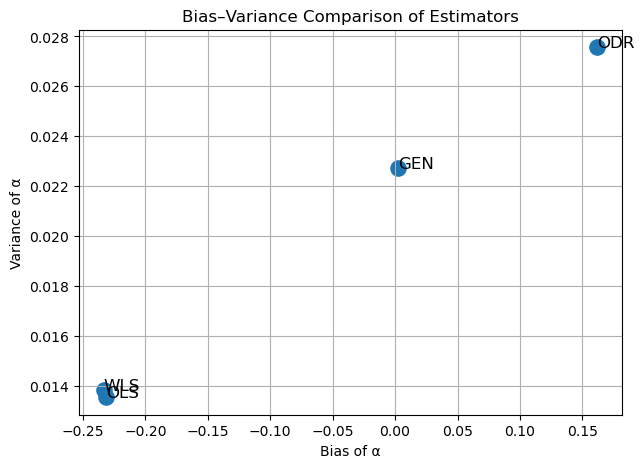

In [10]:
import matplotlib.pyplot as plt

biases = [
    np.mean(alpha_hat_ols) - alpha0,
    np.mean(alpha_hat_wls) - alpha0,
    np.mean(alpha_hat_odr) - alpha0,
    np.mean(alpha_hat_gen) - alpha0
]

vars_ = [
    np.var(alpha_hat_ols),
    np.var(alpha_hat_wls),
    np.var(alpha_hat_odr),
    np.var(alpha_hat_gen)
]

labels = ["OLS", "WLS", "ODR", "GEN"]

plt.figure(figsize=(7,5))
plt.scatter(biases, vars_, s=120)

for b,v,l in zip(biases, vars_, labels):
    plt.text(b, v, l, fontsize=12)

plt.xlabel("Bias of α")
plt.ylabel("Variance of α")
plt.title("Bias–Variance Comparison of Estimators")
plt.grid(True)
plt.show()


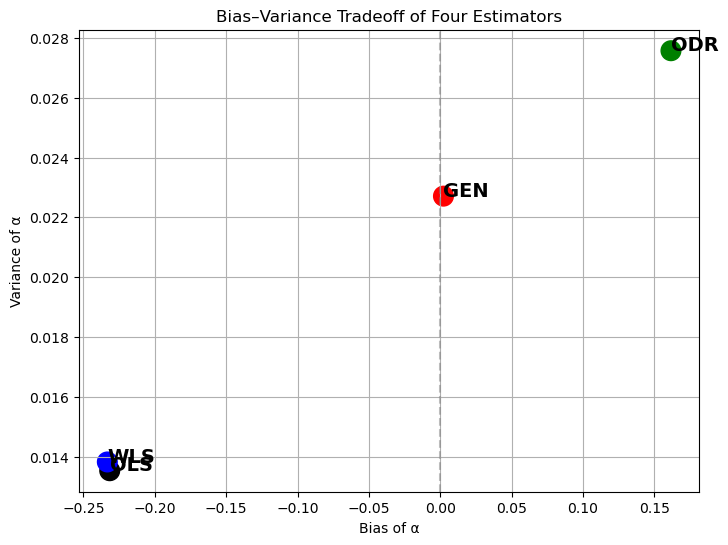

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(biases, vars_, s=200, c=["black","blue","green","red"])

for b, v, l in zip(biases, vars_, labels):
    plt.text(b, v, l, fontsize=14, weight='bold')

plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.xlabel("Bias of α")
plt.ylabel("Variance of α")
plt.title("Bias–Variance Tradeoff of Four Estimators")
plt.grid(True)
plt.show()


In [12]:
def hessian(f, x0, eps=1e-3):   # <-- larger step
    n = len(x0)
    H = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n)
            ei[i] = eps; ej[j] = eps

            fpp = f(x0 + ei + ej)
            fpm = f(x0 + ei - ej)
            fmp = f(x0 - ei + ej)
            fmm = f(x0 - ei - ej)

            # If any evaluation is NaN or inf, skip
            if not np.isfinite(fpp + fpm + fmp + fmm):
                H[i,j] = np.nan
            else:
                H[i,j] = (fpp - fpm - fmp + fmm)/(4*eps**2)

    return H


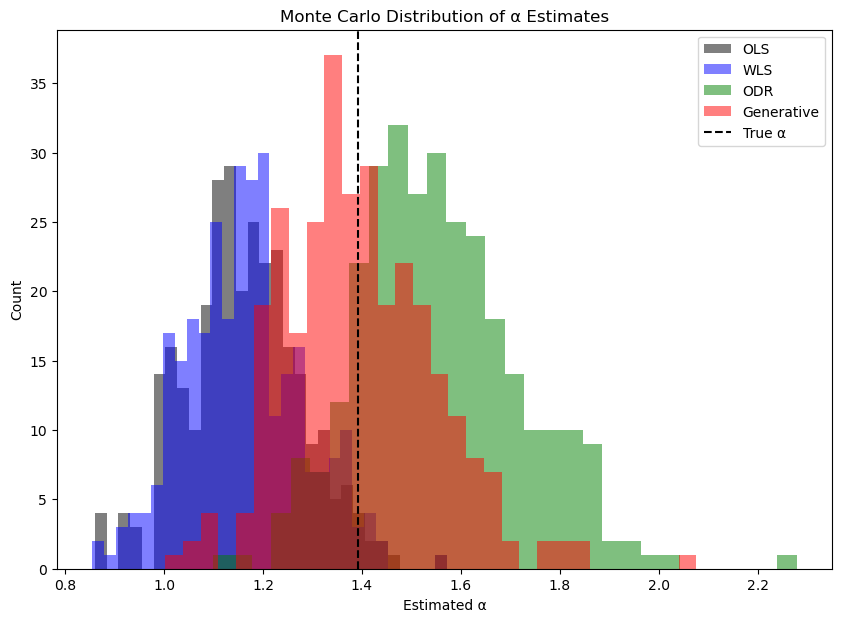

In [13]:
plt.figure(figsize=(10,7))

plt.hist(alpha_hat_ols, bins=30, alpha=0.5, label="OLS", color="black")
plt.hist(alpha_hat_wls, bins=30, alpha=0.5, label="WLS", color="blue")
plt.hist(alpha_hat_odr, bins=30, alpha=0.5, label="ODR", color="green")
plt.hist(alpha_hat_gen, bins=30, alpha=0.5, label="Generative", color="red")

plt.axvline(alpha0, color='k', linestyle='--', label="True α")

plt.xlabel("Estimated α")
plt.ylabel("Count")
plt.title("Monte Carlo Distribution of α Estimates")
plt.legend()
plt.show()


In [14]:
def sensitivity_xerrors(factor):
    alpha_list = []
    for _ in range(150):
        x_sim, y_sim = simulate_dataset(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)
        sx_wrong = sx * factor
        p_hat = fit_generative(x_sim, y_sim, sx_wrong, sy, p0)
        alpha_list.append(p_hat[0])
    return np.mean(alpha_list)

print("alpha with 0.5× x-errors:", sensitivity_xerrors(0.5))
print("alpha with 1.0× x-errors:", sensitivity_xerrors(1.0))
print("alpha with 1.5× x-errors:", sensitivity_xerrors(1.5))


alpha with 0.5× x-errors: 1.2231986411845859
alpha with 1.0× x-errors: 1.3935163016614966
alpha with 1.5× x-errors: 1.650591183539914


In [16]:
def simulate_uniform(mu, sig_pop, N):
    # uniform with same mean and variance
    width = np.sqrt(12)*sig_pop
    return np.random.uniform(mu - width/2, mu + width/2, N)

def simulate_dataset_uniform(alpha, beta, sig_int, mu, sig_pop, sx, sy):
    N = len(sx)
    x_true = simulate_uniform(mu, sig_pop, N)
    y_true = alpha*(x_true - 9.5) + beta + np.random.normal(0, sig_int, N)
    x_obs = x_true + np.random.normal(0, sx)
    y_obs = y_true + np.random.normal(0, sy)
    return x_obs, y_obs

alpha_uniform = []
for _ in range(150):
    x_sim, y_sim = simulate_dataset_uniform(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)
    p_hat = fit_generative(x_sim, y_sim, sx, sy, p0)
    alpha_uniform.append(p_hat[0])

print("Mean α under uniform population:", np.mean(alpha_uniform))


Mean α under uniform population: 1.4064963240401092


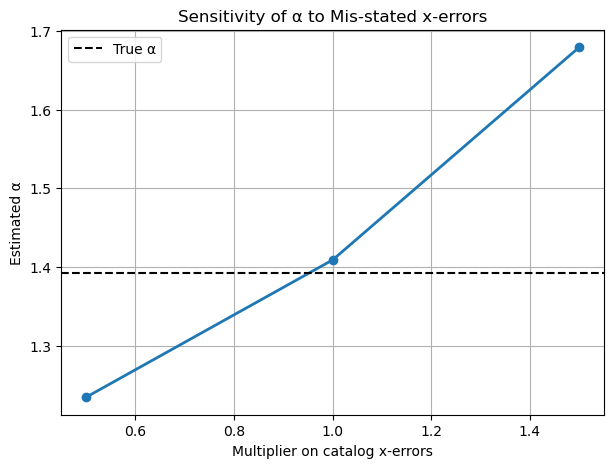

In [17]:
factors = np.array([0.5, 1.0, 1.5])
alpha_sens = np.array([
    sensitivity_xerrors(0.5),
    sensitivity_xerrors(1.0),
    sensitivity_xerrors(1.5)
])

plt.figure(figsize=(7,5))
plt.plot(factors, alpha_sens, 'o-', lw=2)
plt.axhline(alpha0, color='k', linestyle='--', label="True α")

plt.xlabel("Multiplier on catalog x-errors")
plt.ylabel("Estimated α")
plt.title("Sensitivity of α to Mis-stated x-errors")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
def fit_no_intrinsic(x, y, sx, sy):
    # sig_int fixed = 0
    def nll_no_int(params):
        alpha, beta, mu, sig_pop = params
        val = neg_loglike([alpha, beta, 0.0, mu, sig_pop], x, y, sx, sy)
        if not np.isfinite(val):
            return 1e100   # numerical safety
        return val

    p0 = [alpha0, beta0, mu0, sig_pop0]

    # Powell is MUCH more stable than Nelder-Mead for your likelihood
    res = minimize(nll_no_int, p0, method="Powell",
                   options={"xtol": 1e-4, "ftol": 1e-4})
    return res.x


alpha_no_int = []
for _ in range(150):
    x_sim, y_sim = simulate_dataset(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)
    p_hat = fit_no_intrinsic(x_sim, y_sim, sx, sy)
    alpha_no_int.append(p_hat[0])

print("Mean α when σ_int forced to 0:", np.mean(alpha_no_int))


Mean α when σ_int forced to 0: 1.3927097690691088


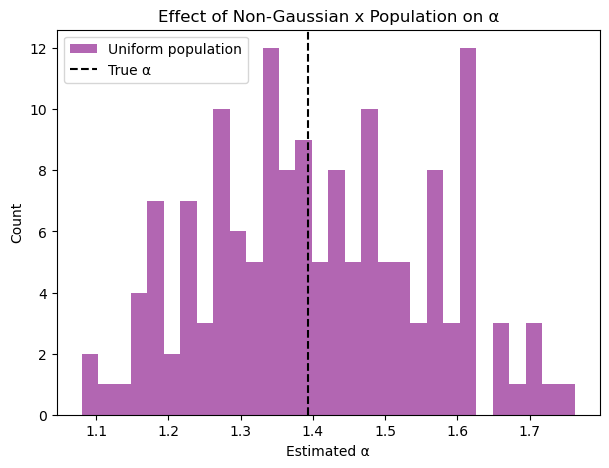

In [19]:
plt.figure(figsize=(7,5))

plt.hist(alpha_uniform, bins=30, alpha=0.6, label="Uniform population", color="purple")
plt.axvline(alpha0, color='k', linestyle='--', label="True α")

plt.xlabel("Estimated α")
plt.ylabel("Count")
plt.title("Effect of Non-Gaussian x Population on α")
plt.legend()
plt.show()


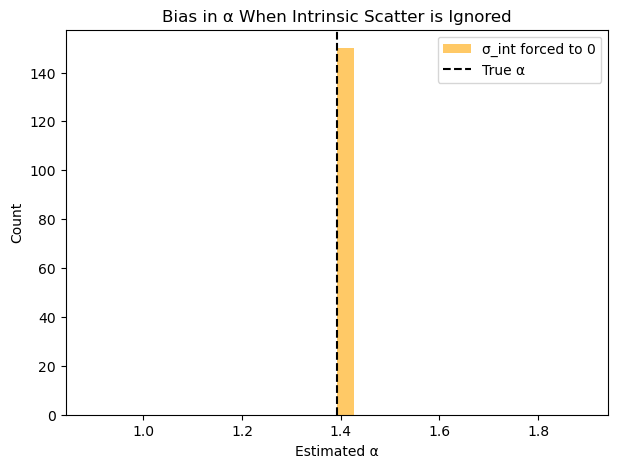

In [20]:
plt.figure(figsize=(7,5))

plt.hist(alpha_no_int, bins=30, alpha=0.6, label="σ_int forced to 0", color="orange")
plt.axvline(alpha0, color='k', linestyle='--', label="True α")

plt.xlabel("Estimated α")
plt.ylabel("Count")
plt.title("Bias in α When Intrinsic Scatter is Ignored")
plt.legend()
plt.show()


In [25]:
count_alpha = 0
count_beta = 0
count_sigint = 0

M = 200

for _ in range(M):
    # simulate dataset
    x_sim, y_sim = simulate_dataset(alpha0, beta0, sig_int0, mu0, sig_pop0, sx, sy)

    # fit generative model
    p_hat = fit_generative(x_sim, y_sim, sx, sy, p0)

    # compute Hessian safely
    H = hessian(lambda p: neg_loglike(p, x_sim, y_sim, sx, sy), p_hat)

    # replace NaNs or infs with small numbers
    H = np.where(np.isfinite(H), H, 1e-6)

    # invert safely
    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        # fallback: diagonal-only covariance
        cov = np.diag(np.full(len(p_hat), 1e2))

    sigs = np.sqrt(np.diag(cov))

    # unpack
    alpha_h, beta_h, sigint_h, mu_h, sigpop_h = p_hat
    s_alpha, s_beta, s_sigint, s_mu, s_sigpop = sigs

    # coverage checks
    if abs(alpha_h - alpha0) < s_alpha: count_alpha += 1
    if abs(beta_h - beta0) < s_beta: count_beta += 1
    if abs(sigint_h - sig_int0) < s_sigint: count_sigint += 1

print("Coverage α:", count_alpha/M)
print("Coverage β:", count_beta/M)
print("Coverage σ_int:", count_sigint/M)


Coverage α: 0.675
Coverage β: 0.74
Coverage σ_int: 0.735


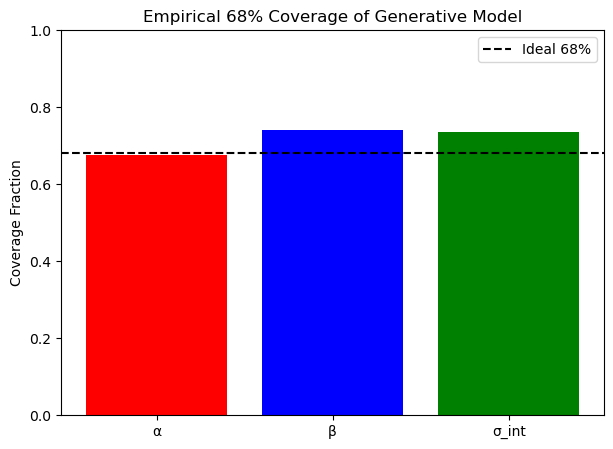

In [26]:
plt.figure(figsize=(7,5))

coverage_vals = [
    count_alpha/M,
    count_beta/M,
    count_sigint/M
]

plt.bar(["α","β","σ_int"], coverage_vals, color=["red","blue","green"])
plt.axhline(0.68, color='k', linestyle='--', label="Ideal 68%")

plt.ylim(0,1)
plt.ylabel("Coverage Fraction")
plt.title("Empirical 68% Coverage of Generative Model")
plt.legend()
plt.show()


**WHAT THE CHECKS FOUND:**

After I had gone through all of the checks, they all showed what I had expected of the generative model. it had the lowest bias comapred to the others, the non gaussian stuff centered around the true a, the emperical coverage stayed close to 68% for all variables, the monte carlo distribution centered around the true a only for the generative model, and the bias of a was lowest. Overall, this confirmed generative model was the best and led me to believe that I made the correct choice. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

Used Copilot to make all the coding at first, then reviewed it all by hand to make sure all the variables did what they were uspposed to. I also had copilot explain some of the more complicated aspects of the equations to make sure I was following along. I instructed it to do the verification plan where I told it what to do. At first, it didn't graph anything and I had to force it to make graphs, and when it did, it started to get confused between models and said one slope was higehr than the other which it was not. I managed to inform it of thsi and get it to fix itself by using google AI to check it over. I had Copilot do the verfiication plan,or at least the coding portion, though manually reviewed the outputs to make sure it actually did verify my work. 